## Regular water waves interacting with an array of submerged impermeable vertical cylinders - Frequency-Domain BEM

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D BEM to simulate the propagation of regular linear water waves interacting with an array of impermeable cylinders.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave structure interaction problem
- Analyse the effect of the mesh refinement on the results
- Compute wave reflection and transmission coefficients
- Compute the force components

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

from MAIN_MESH import MAIN_MESH

import meshio
import numpy as np

from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR
from BEM_UTILS.MATCHING import MATCHING

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.ENERGY_FLUX import ENERGY_FLUX
from BEM_UTILS.NODES_FS import NODES_FS

from BEM_UTILS.FORCE import FORCE

from BEM_UTILS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

**2.1 Physical domain and geometry parameters**

In [2]:
# FLUID DOMAIN
DEPTH = 2.5
WIDTH_CHANNEL = 6*DEPTH

# Structure geometry
RADIO  = 1/2*DEPTH
HEIGHT = 1/2*DEPTH

#     Point 1      2             3               4
#     ↓            ↓             ↓               ↓
#     +------------+-------------+---------------+
#     |            |   Object    |               |
#     |  Incident  |   .......   |  Transmitted  |   y
#     |     →      |   .     .   |               |   ↑
#(0,0)+.....→......|......+......|...............|    → x
#     |     →      |   .     .   |               |
#     |            |   .......   |               |
#     |            |             |               |
#     +------------+-------------+---------------+

# Point 1, 2, 3 and 4
FLUME_LENGTH_X = [0, 3*DEPTH, 5*DEPTH, 8*DEPTH]

# Location of the center's structures in x and y PROCESS_CONNECTIVITY
# The middle of the wave flume is at y=0 
LOC_STRUCT_X = [4*DEPTH, 4*DEPTH, 4*DEPTH]
LOC_STRUCT_Y = [1.5*DEPTH, 0, -1.5*DEPTH]

# Number of structures
N_STRUCT  = len(LOC_STRUCT_X);

# Number of regions: outer and inner regions
NUM_OF_REG = 1

**2.2 Wave parameters and frequency range**

In [3]:
# Number of frequencies / wave cases
ttmax = 15

# Dimensionless wavenumber (k*h)
kh = np.linspace(0.005, 3.00, ttmax)

# Wave steepness H/λ
HL = 0.01

**3. Mesh**

In [4]:
# GMSH meshes
MAIN_MESH(DEPTH,WIDTH_CHANNEL,RADIO,HEIGHT,FLUME_LENGTH_X,LOC_STRUCT_X,LOC_STRUCT_Y)

In [5]:
# Read the Gmsh file and extract node and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("OUTER_REGION.msh")

In [6]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [7]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)

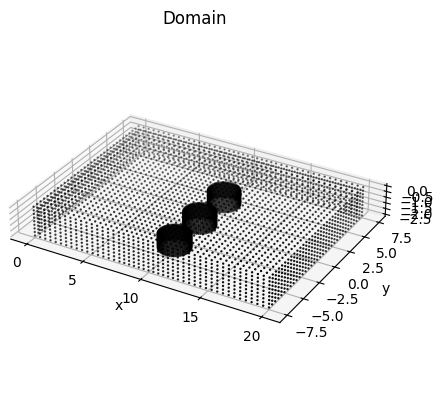

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=0.5
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_0_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [10]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)

In [11]:
# Total number of nodes and elements
N_total  = np.sum(N)
NE_total = np.sum(NE)

**4. Influence matrices**

In [12]:
# Form H and B matrices for each region
H , G = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);

**5. Frequency loop and boundary condition application**

In [16]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

# Preallocate arrays for force components
FX_1 = np.zeros(ttmax,dtype=complex)
FY_1 = np.zeros(ttmax,dtype=complex)
FZ_1 = np.zeros(ttmax,dtype=complex)

FX_2 = np.zeros(ttmax,dtype=complex)
FY_2 = np.zeros(ttmax,dtype=complex)
FZ_2 = np.zeros(ttmax,dtype=complex)

FX_3 = np.zeros(ttmax,dtype=complex)
FY_3 = np.zeros(ttmax,dtype=complex)
FZ_3 = np.zeros(ttmax,dtype=complex)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, NE, 0)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN(A, B, k, NCONEC,  NORMAL_0, REF_R0["IN"],  KCONEC_0, NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NCONEC, NORMAL_0, REF_R0["OUT"], KCONEC_0, NE, 0)

    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC_0[0:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC_0, N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Incident wave energy flux   
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R0["OUT"], MESH_0_POS,
        KCONEC_0,
        N, NE, 0, 0)    

    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)
    
    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]      

    # Force components
    FX_1[tt], FY_1[tt], FZ_1[tt] = FORCE(Coef_S, MESH_0_POS, NCONEC, REF_R0["POROUS_31"], KCONEC_0, N, NE, 0)
    FX_2[tt], FY_2[tt], FZ_2[tt] = FORCE(Coef_S, MESH_0_POS, NCONEC, REF_R0["POROUS_32"], KCONEC_0, N, NE, 0)
    FX_3[tt], FY_3[tt], FZ_3[tt] = FORCE(Coef_S, MESH_0_POS, NCONEC, REF_R0["POROUS_33"], KCONEC_0, N, NE, 0)

# END LOOPS

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


**6. Results**

**6.1 Evergy coefficients**

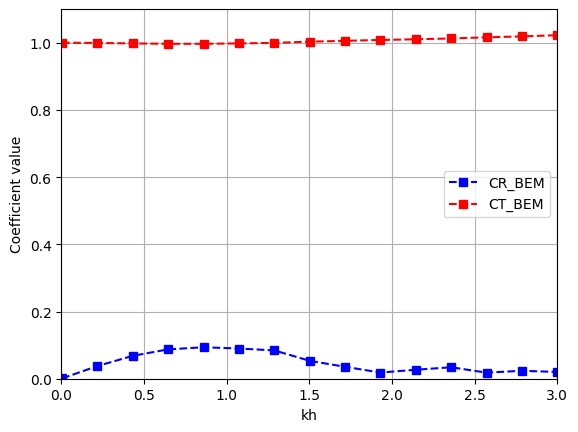

In [33]:
plt.figure(15)

plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CT_BEM')

plt.xlim([0, 3.00])
plt.ylim([0, 1.10])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

plt.show()

**6.2 Force components**

<Figure size 640x480 with 0 Axes>

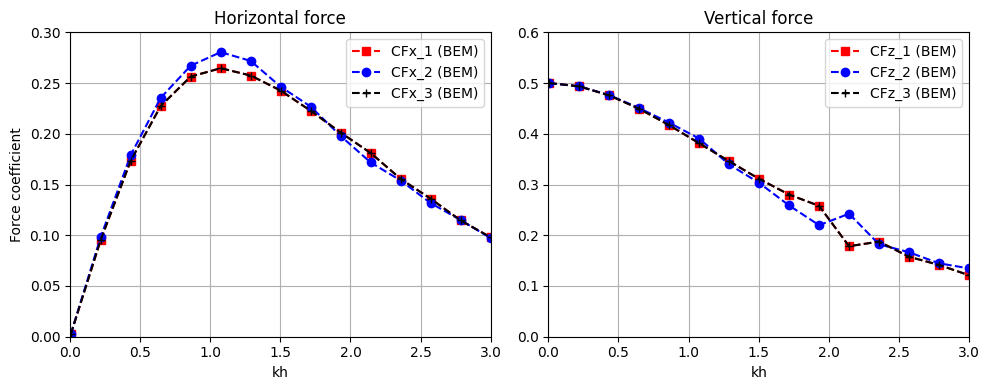

In [30]:
plt.figure(100)

TERM = (np.pi*rho*gravity*2*WAVE["Amp"]*RADIO**2)

CFX_1 = np.abs(rho*WAVE["omega"]*( FX_1 ))/TERM
CFZ_1 = np.abs(rho*WAVE["omega"]*( FZ_1 ))/TERM

CFX_2 = np.abs(rho*WAVE["omega"]*( FX_2 ))/TERM
CFZ_2 = np.abs(rho*WAVE["omega"]*( FZ_2 ))/TERM

CFX_3 = np.abs(rho*WAVE["omega"]*( FX_3 ))/TERM
CFZ_3 = np.abs(rho*WAVE["omega"]*( FZ_3 ))/TERM

# Create figure with 2 plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# --- Horizontal force ---
ax1.plot(kh, CFX_1, 'r--s', label='CFx_1 (BEM)')
ax1.plot(kh, CFX_2, 'b--o', label='CFx_2 (BEM)')
ax1.plot(kh, CFX_3, 'k--+', label='CFx_3 (BEM)')
ax1.set_xlim([0,3])
ax1.set_ylim([0,0.30])
ax1.set_xlabel('kh')
ax1.set_ylabel('Force coefficient')
ax1.set_title('Horizontal force')
ax1.grid(True)
ax1.legend()

# --- Vertical force ---
ax2.plot(kh, CFZ_1, 'r--s', label='CFz_1 (BEM)')
ax2.plot(kh, CFZ_2, 'b--o', label='CFz_2 (BEM)')
ax2.plot(kh, CFZ_3, 'k--+', label='CFz_3 (BEM)')
ax2.set_xlim([0,3])
ax2.set_ylim([0,0.60])
ax2.set_xlabel('kh')
ax2.set_title('Vertical force')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig("FX_FZ_side_by_side_IMPERMEABLE.pdf")
plt.show()

**6.3 Free surface**

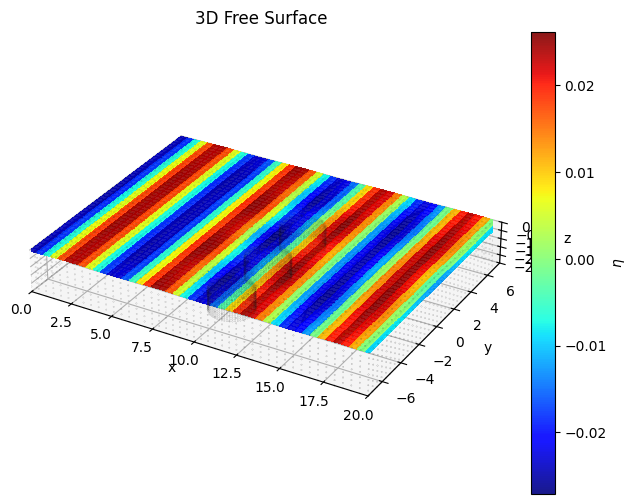

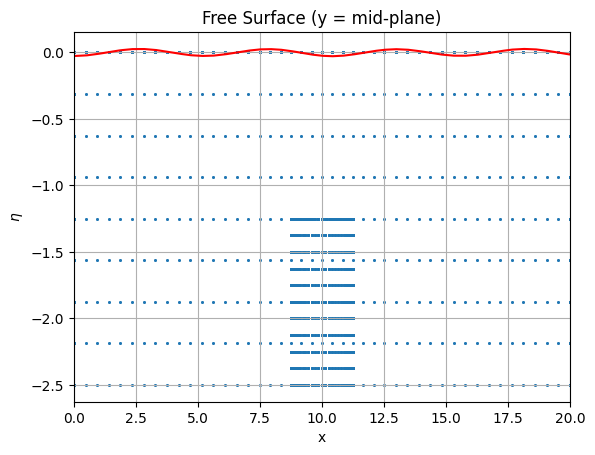

In [45]:
# Free surface
PHI_R = VISUAL_FREE_SURFACE(Coef_S, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R0["FS"], MESH_0_POS, MESH_0_POS, KCONEC_0, N, NE, 0)